### Differential evolution fitting with SpammsFit

This notebook demonstrates how to perform spectral fitting of an observed spectrum using SPAMMSFit with a differential evolution algorithm.

SpammsFit is used directly from the source dir and no need for any pre-installation required. A local SPAMMS installation is needed but not necessarily should be in the same  dir as SpammsFit.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [2]:
SPAMMSFIT_DIR = Path.home() / "SpammsFit" # Path to the local SpammsFit repository.
SPAMMSFIT_SRC = SPAMMSFIT_DIR / "src" # temporarily import the spammsfit source package 
if not SPAMMSFIT_SRC.is_dir():
    raise FileNotFoundError(f"Could not find the SpammsFit source directory: {SPAMMSFIT_SRC}")
if str(SPAMMSFIT_SRC) not in sys.path:
    sys.path.insert(0, str(SPAMMSFIT_SRC))
import spammsfit as spfit
import spammsfit.plotting as spplot

#### Configure SpammsFit to point to the local SPAMMS installation

In [5]:
SPAMMS_DIR = Path.home() / "PhD_stuff" / "SPAMMS" # Change this path to the user's local SPAMMS installation.
config = spfit.SpammsConfig(
    spamms_directory=SPAMMS_DIR,
    spamms_script=SPAMMS_DIR / "spamms.py", #path to the local main spamms.py file
    temporary_directory=SPAMMSFIT_DIR / "examples" / "outputs" / "bayesian_temp",  #temporary file storage during spamms runs
    results_directory=SPAMMSFIT_DIR / "examples" / "results" / "bayesian_results", # output folder
    )

#### Load data

We are using an example spectrum of a HeII 4200 profile for a star with $T_{eff}$ = 40000, $M/M_\odot$ = 25, $R/R_\odot$ = 6.5.

Replace your own data and  read-data functions.

In [8]:
data = np.loadtxt('/home/c4011027/PhD_stuff/SPAMMS/Outputs/results/obs_profiles/noisy_spectra/inc87_vcrit0.83_R149_T197_SN500.txt')
wavelength, flux = data[:, 0], data[:, 1]

# The uncerstainties are used as weights. Replace the corresponding SNR for the spectrum - or use the flux errors for individual wavelength bins if available, directly.
SNR = 500.0 
flux_uncertainty = np.full_like(flux, 1.0 / SNR)

# make a spectrum object
spectrum = spfit.Spectrum(wavelength=wavelength, flux=flux,uncertainty=flux_uncertainty)

In [12]:
print(spectrum)
print(f"Number of wavelength points: {wavelength.size}")
print(f"Wavelength range: {wavelength.min():.2f} -- {wavelength.max():.2f} Å")
print(f"Assumed flux uncertainty: {1.0 / SNR:.5f}")

Spectrum(name=None, size=11911, n_lines=0, n_fitting_pixels=0)
Number of wavelength points: 11911
Wavelength range: 4138.70 -- 4257.80 Å
Assumed flux uncertainty: 0.00200


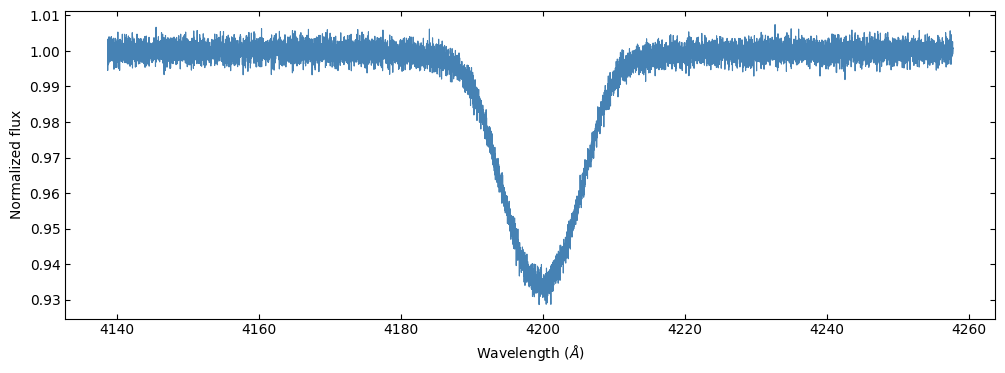

In [15]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(wavelength, flux, color="steelblue", linewidth=0.8)
ax.set_xlabel(r"Wavelength ($\AA$)")
ax.set_ylabel("Normalized flux")
ax.tick_params(direction="in", top=True, right=True)

plt.show()

#### Add and Remove lines for analysis

add_line takes the nmae of the line species that you want to add. The name should be same as used by SPAMMS (i.e. in capital letters )

remove_line only needs the species names for removing a line from the selected linelist.

Overwrite option is to replace an already added line with updated fitting ranges

In [22]:
spectrum.add_line(name="HEII4200", fitting_range=(4180.0, 4220.0), overwrite = True) 
spectrum.add_line(name="HEI4471", fitting_range=(4160.0, 4175.0), overwrite = True)
print("Selected lines:", spectrum.line_names)

Selected lines: ('HEII4200', 'HEI4471')


In [23]:
spectrum.remove_line("HEI4471")
print("Selected lines after removal:", spectrum.line_names)

Selected lines after removal: ('HEII4200',)


#### Set the input file and parameter sets for fitting

parameters.fix for setting a parameter to a constant value.

Only the free paramteres will enter the optimization. The parameter bounds should be provided as (lower_bound, upper_bound)

In [28]:
parameters = spfit.ParameterSet(input_file=SPAMMS_DIR / "input.txt")
parameters.fix(teff=40000, r_pole=6.5, mass=25)
parameters.free(inclination=(10.0, 90.0), v_crit_frac=(0.1, 0.9), sigma_R=(50.0, 300.0), sigma_T=(50.0, 300.0))

In [27]:
print(parameters.summary())
print("Free parameters:", parameters.free_names())
print("Initial vector:", parameters.initial_vector())
print("Bounds:", parameters.continuous_bounds())

SPAMMS input file: /home/c4011027/PhD_stuff/SPAMMS/input.txt
Selected lines: HEII4200, HEI4026, HEI4387
Parameters:
  ntriangles: fixed at 10000
  teff: fixed at 40000.0
  r_pole: fixed at 6.5
  mass: fixed at 25.0
  inclination: free continuous, bounds=(10.0, 90.0)
  v_crit_frac: free continuous, bounds=(0.1, 0.9)
  sigma_R: free continuous, bounds=(50.0, 300.0)
  sigma_T: free continuous, bounds=(50.0, 300.0)
Free parameters: ('inclination', 'v_crit_frac', 'sigma_R', 'sigma_T')
Initial vector: [ 87.     0.83 272.   197.  ]
Bounds: ((10.0, 90.0), (0.1, 0.9), (50.0, 300.0), (50.0, 300.0))


#### pre-fitting steps

Next step is to create a spammsfit object with the spectrum, the parameter set and the temporary configuration we created previously

In [ ]:
spamms_fit = spfit.SpammsFit(spectrum=spectrum, parameters=parameters, config=config)